# DLWA Analysis: GC-free vs Host-triggered GC

Comparing two zone management strategies on ZNS SSD (ConfZNS++) across different `finish_threshold` values.

- **GC-free** (`gc_mode=False`): zone finished early, no host GC, higher DLWA
- **Host GC** (`gc_mode=True`): delayed FINISH, GC mixes data by lifetime, lower DLWA but GC overhead

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

## Baseline

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

METRICS = [
    ("total_pages_to_write",  "Dummy Data Writes (LBAs)"),
    ("finish_call_count",     "Finish Call Count"),
    ("latency_micros_per_op", "Latency (µs/op)"),
    ("throughput_MB_per_s",   "Throughput (MB/s)"),
]

def _read_csv(f):
    return pd.read_csv(f)

def _detect_xcol(df):
    if df["finish_threshold"].nunique() == 1:
        return "gc_start_level"
    return "finish_threshold"

def _make_label(df):
    gc_mode = df["gc_mode"].iloc[0]
    xcol = _detect_xcol(df)
    base = "Host GC" if gc_mode else "GC-free"
    if xcol == "finish_threshold":
        level = df["gc_start_level"].iloc[0]
        suffix = "" if pd.isna(level) or str(level) == "N/A" else f" (level {level})"
    else:
        thresh = df["finish_threshold"].iloc[0]
        suffix = f" (thresh {thresh}%)"
    return base + suffix

def plot(title, files, metric=None, yscale="linear"):
    """One line per file.

    metric: column name to plot a single figure;
            if None, plots all 4 metrics in a 2x2 grid.
    """
    metric_map = dict(METRICS)
    if metric is not None and metric not in metric_map:
        raise ValueError(f"metric must be one of {list(metric_map)}")

    lines = []
    xcols = set()
    for f in files:
        df = _read_csv(f)
        xcol = _detect_xcol(df)
        xcols.add(xcol)
        lines.append((df.sort_values(xcol), xcol, _make_label(df)))
    xlabel = "finish_threshold (%)" if "finish_threshold" in xcols else "gc_start_level (%)"

    if metric is None:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(title, fontsize=13)
        for ax, (col, ylabel) in zip(axes.flat, METRICS):
            for df, xcol, label in lines:
                ax.plot(df[xcol], df[col], marker="o", linestyle="--", label=label)
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.set_title(ylabel)
            ax.set_yscale(yscale)
            ax.legend(fontsize=8)
            ax.grid(True)
    else:
        ylabel = metric_map[metric]
        fig, ax = plt.subplots(figsize=(7, 5))
        fig.suptitle(f"{title} — {ylabel}", fontsize=12)
        for df, xcol, label in lines:
            ax.plot(df[xcol], df[metric], marker="o", linestyle="--", label=label)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_yscale(yscale)
        ax.legend(fontsize=8)
        ax.grid(True)

    plt.tight_layout()
    plt.show()


In [4]:
def average_runs(files, output):
    """Average the 4 metrics across multiple run CSVs and write the result to output.

    Rows are matched by (benchmark, num_ops, gc_mode, gc_start_level, finish_threshold).
    Returns the averaged DataFrame.
    """
    METRIC_COLS = [col for col, _ in METRICS]
    KEY_COLS = ["benchmark", "num_ops", "gc_mode", "gc_start_level", "finish_threshold"]

    combined = pd.concat([_read_csv(f) for f in files], ignore_index=True)
    avg = (combined.groupby(KEY_COLS, dropna=False)[METRIC_COLS]
                   .mean()
                   .reset_index()
                   .sort_values(_detect_xcol(combined)))
    avg.to_csv(output, index=False)
    print(f"Saved {len(avg)} rows → {output}")
    return avg


## Experiment 1: Varying Finish Threshold Under Default Settings

In [5]:
average_runs(
    [
        "../results/exp1/fillrandom_3M_gcfalse_2.csv",
        "../results/exp1/fillrandom_3M_gcfalse_3.csv",
        "../results/exp1/fillrandom_3M_gcfalse_4.csv",

    ],
    "../results/exp1/fillrandom_3M_gcfalse_avg.csv",
)

Saved 9 rows → ../results/exp1/fillrandom_3M_gcfalse_avg.csv


,benchmark,num_ops,gc_mode,gc_start_level,finish_threshold,total_pages_to_write,finish_call_count,latency_micros_per_op,throughput_MB_per_s
0,fillrandom,3000000,False,NaN,0,0.000000e+00,0.000000,26.765667,37.066667
1,fillrandom,3000000,False,NaN,10,7.685900e+04,6.000000,27.176000,36.566667
2,fillrandom,3000000,False,NaN,20,7.539167e+04,4.333333,27.858667,35.600000
3,fillrandom,3000000,False,NaN,30,1.812192e+06,16.333333,31.274333,31.733333
4,fillrandom,3000000,False,NaN,40,2.264634e+06,18.000000,30.274000,32.800000
5,fillrandom,3000000,False,NaN,50,4.634728e+06,24.666667,33.963667,29.200000
6,fillrandom,3000000,False,NaN,60,1.037129e+07,42.333333,42.168333,23.533333
7,fillrandom,3000000,False,NaN,70,1.261434e+07,49.333333,45.473000,22.066667
8,fillrandom,3000000,False,NaN,80,2.895589e+07,88.000000,66.923000,14.833333


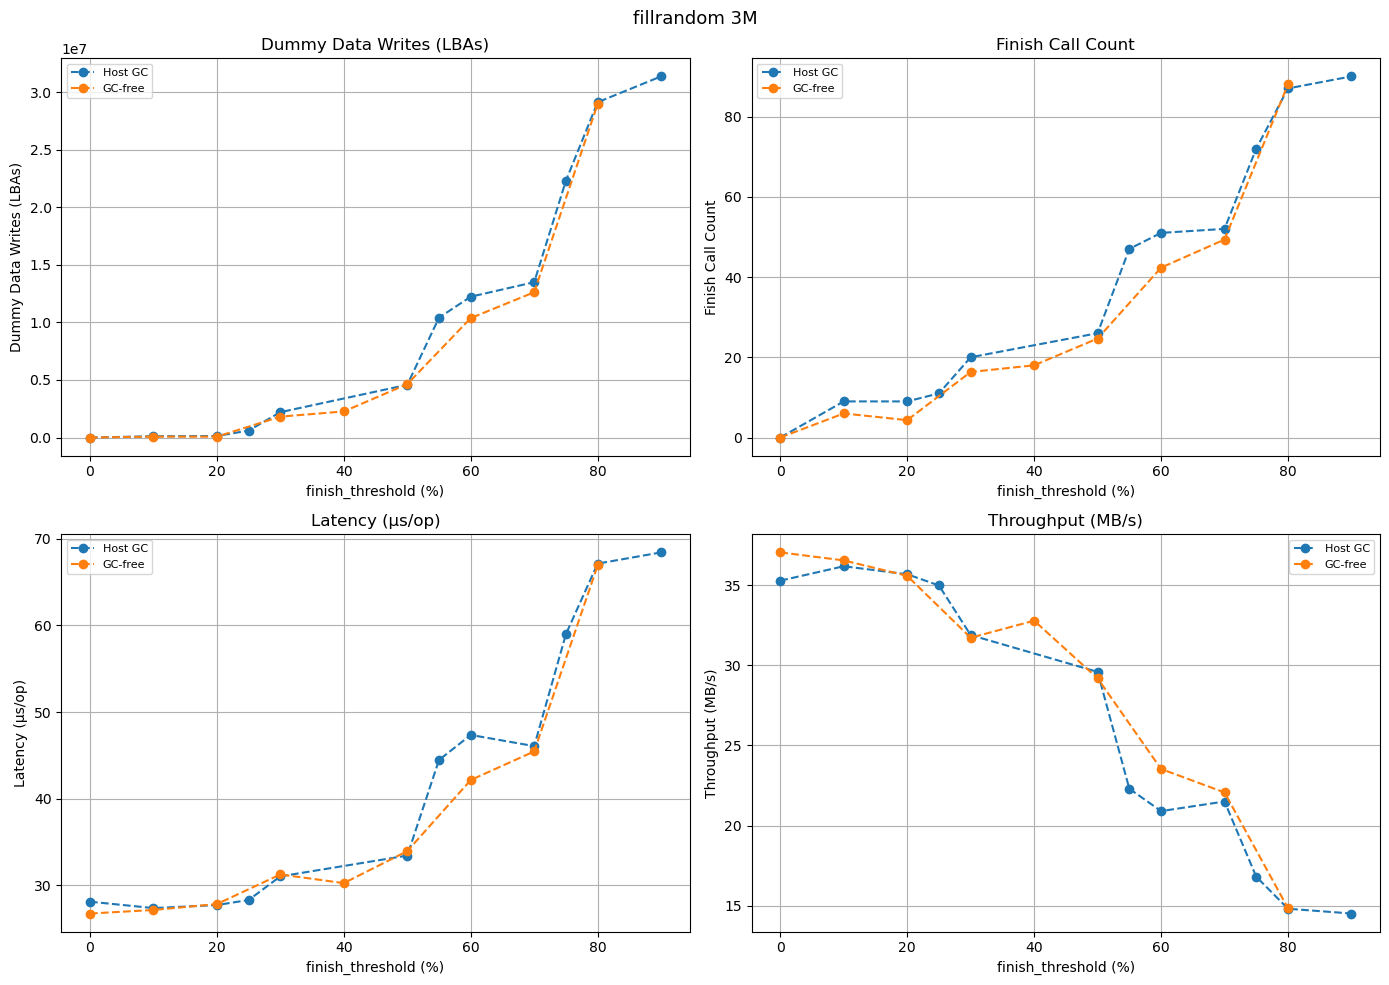

In [6]:
plot(
    "fillrandom 3M",
    [
        "../results/exp1/fillrandom_3M_gc20.csv",
        "../results/exp1/fillrandom_3M_gcfalse_avg.csv",
    ],
)


## Exp 2: High Volume Under Low Thresh

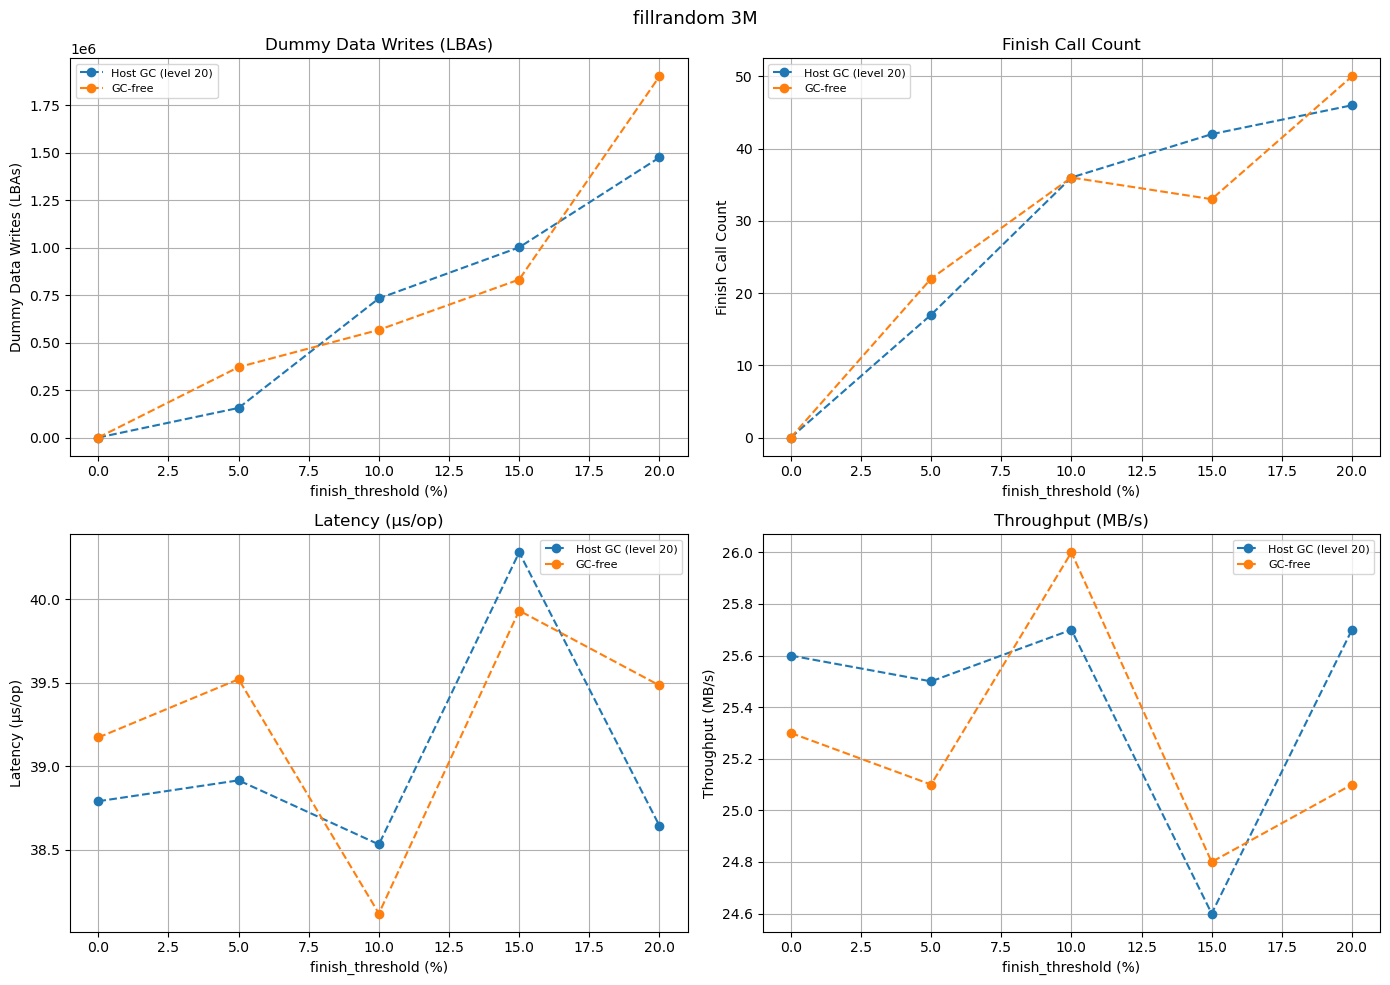

In [7]:
plot(
    "fillrandom 3M",
    [
        "../results/exp2/fillrandom_7M_gc20.csv",
        "../results/exp2/fillrandom_7M_gcfalse.csv",
    ],
)

## Exp 3: GC Under High GC_START_LEVEL(100)

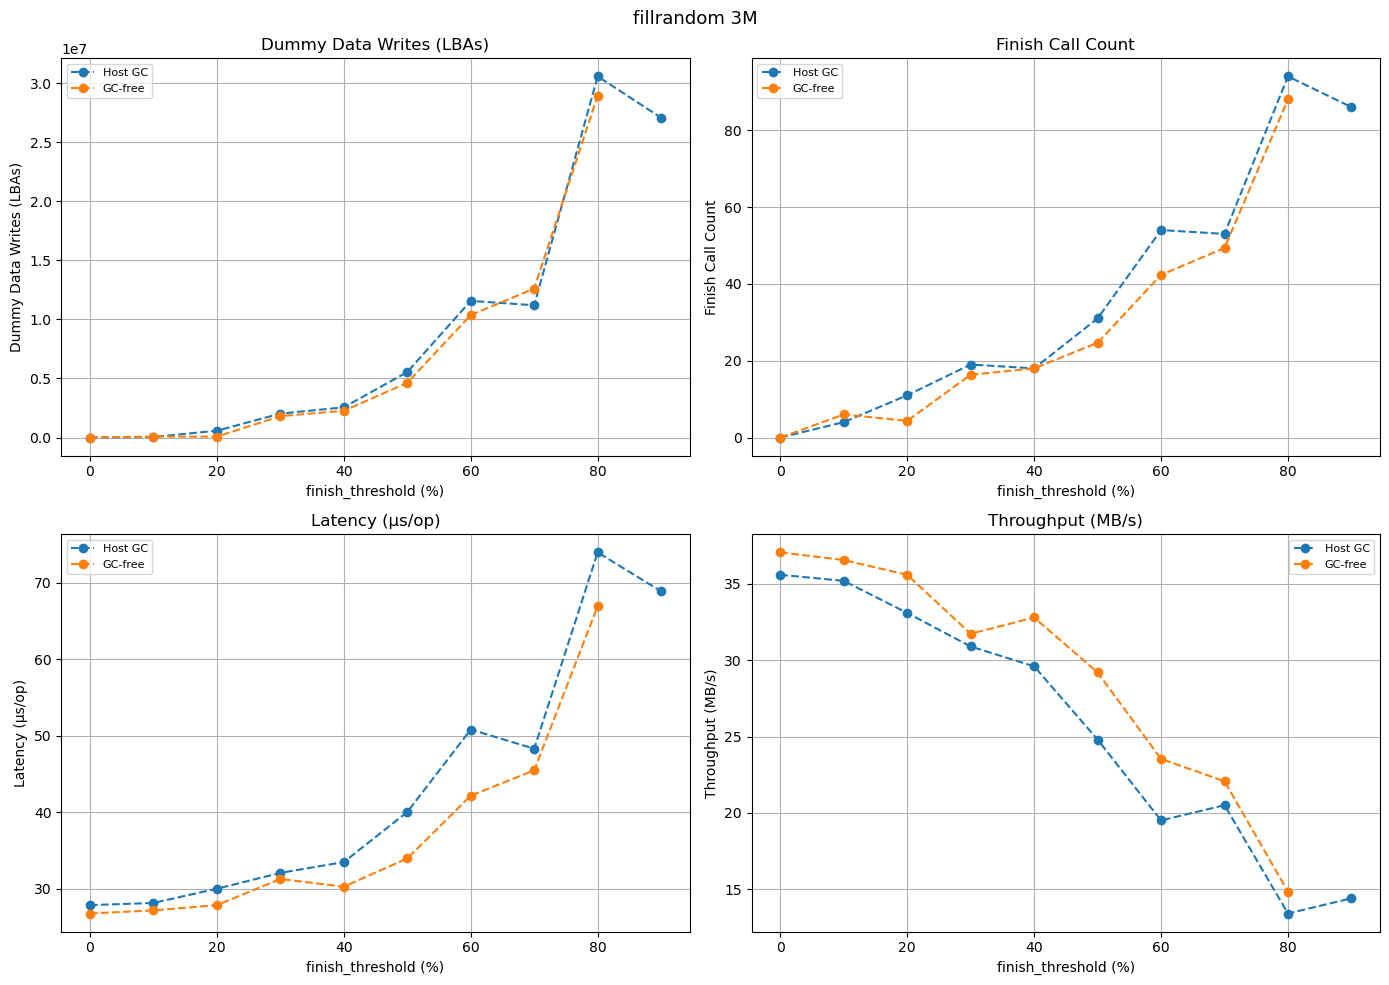

In [8]:
plot(
    "fillrandom 3M",
    [
        "../results/exp3/fillrandom_3M_gc100.csv",
        "../results/exp3/fillrandom_3M_gcfalse_avg.csv",
    ],
)

## Exp 4: Varying gc_start_level



Saved 8 rows → ../results/exp4/fillrandom_7M_thresh20_avg.csv
Saved 8 rows → ../results/exp4/fillrandom_7M_gcfalse_avg.csv


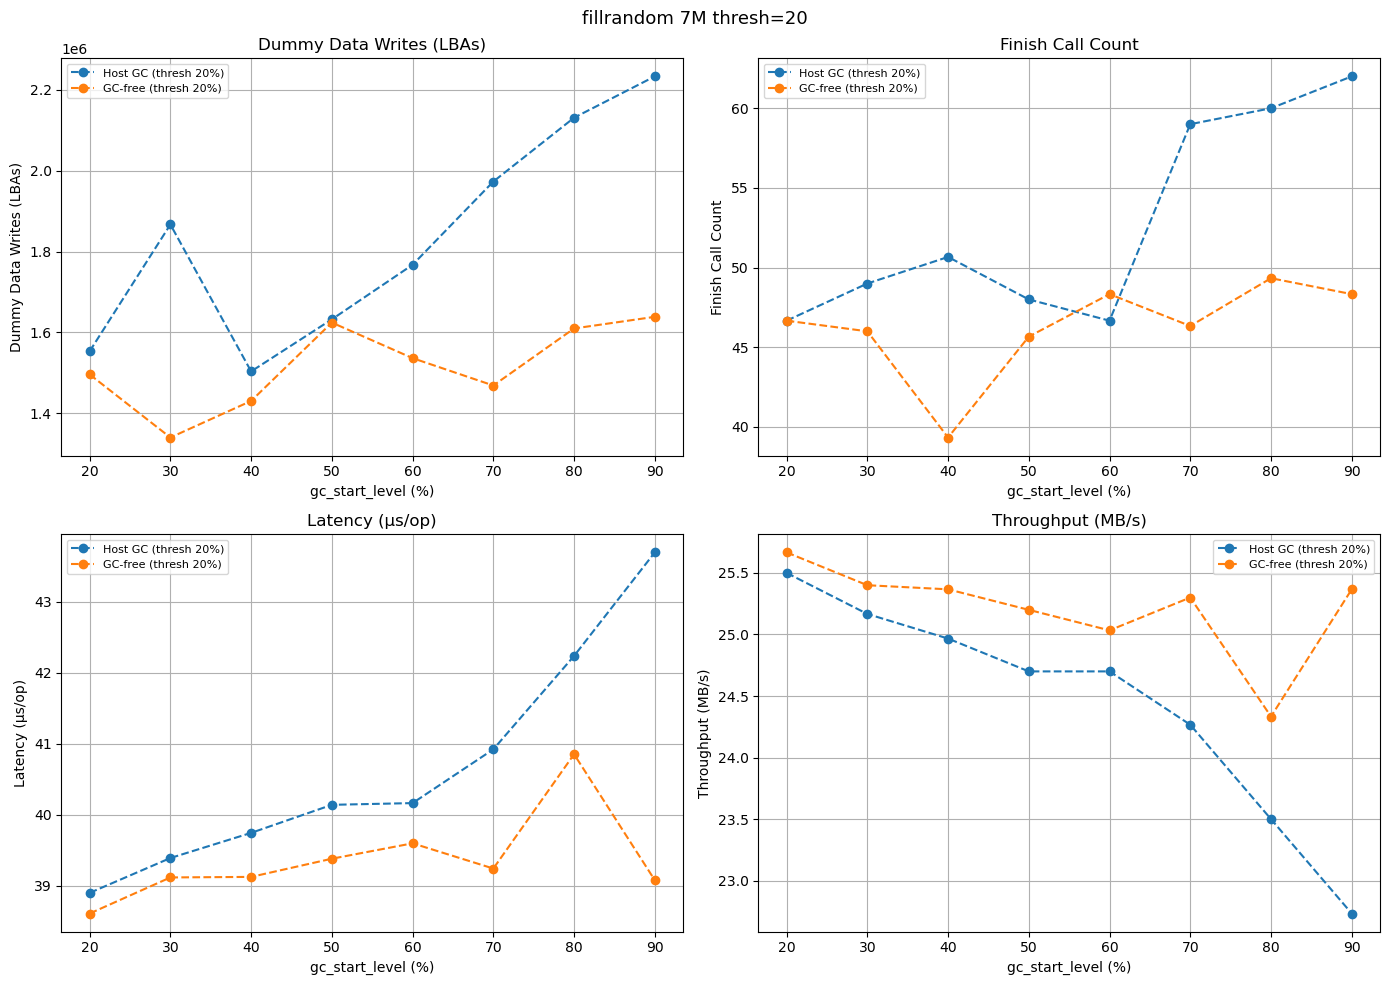

In [9]:
average_runs(
    [
        "../results/exp4/fillrandom_7M_thresh20_1.csv",
        "../results/exp4/fillrandom_7M_thresh20_2.csv",
        "../results/exp4/fillrandom_7M_thresh20_3.csv",
    ],
    "../results/exp4/fillrandom_7M_thresh20_avg.csv",
)

average_runs(
    [
        "../results/exp4/fillrandom_7M_thresh20_gcfalse_1.csv",
        "../results/exp4/fillrandom_7M_thresh20_gcfalse_2.csv",
        "../results/exp4/fillrandom_7M_thresh20_gcfalse_3.csv",
    ],
    "../results/exp4/fillrandom_7M_gcfalse_avg.csv",
)

plot(
    "fillrandom 7M thresh=20",
    [
        "../results/exp4/fillrandom_7M_thresh20_avg.csv",
        "../results/exp4/fillrandom_7M_gcfalse_avg.csv",
    ],
)


## Other Workloads

Saved 9 rows → ../results/fillseq_3M_gcfalse_avg.csv


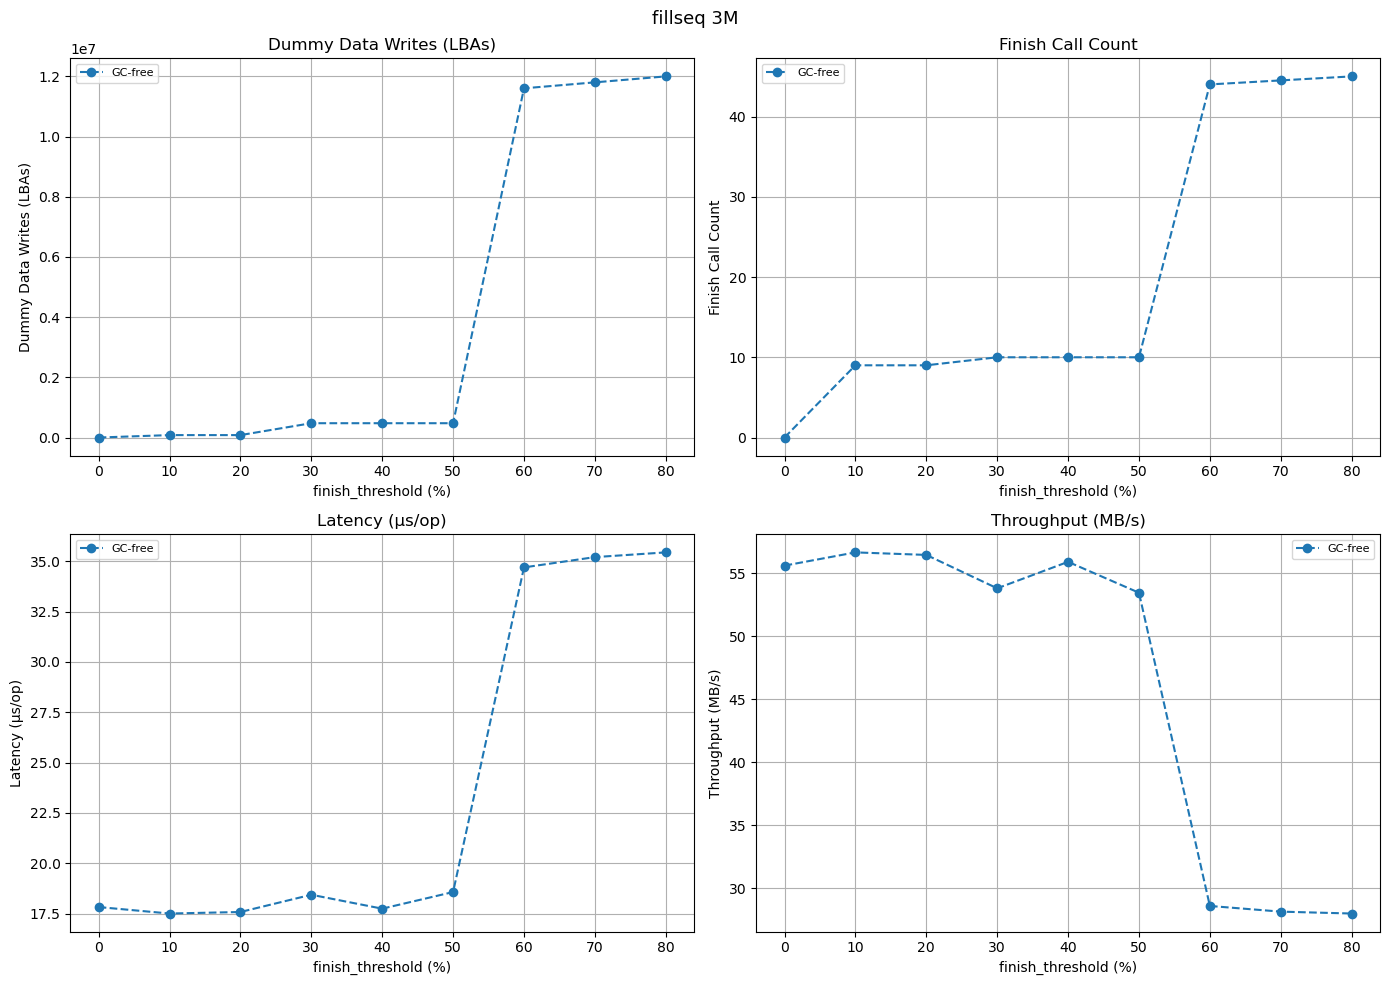

In [12]:
average_runs(
    [
        "../results/fillseq_3M_gcfalse.csv",
        "../results/fillseq_3M_gcfalse_2.csv",
    ],
        "../results/fillseq_3M_gcfalse_avg.csv",
)

plot(
    "fillseq 3M",
    [
        "../results/fillseq_3M_gcfalse_avg.csv",
    ],
)

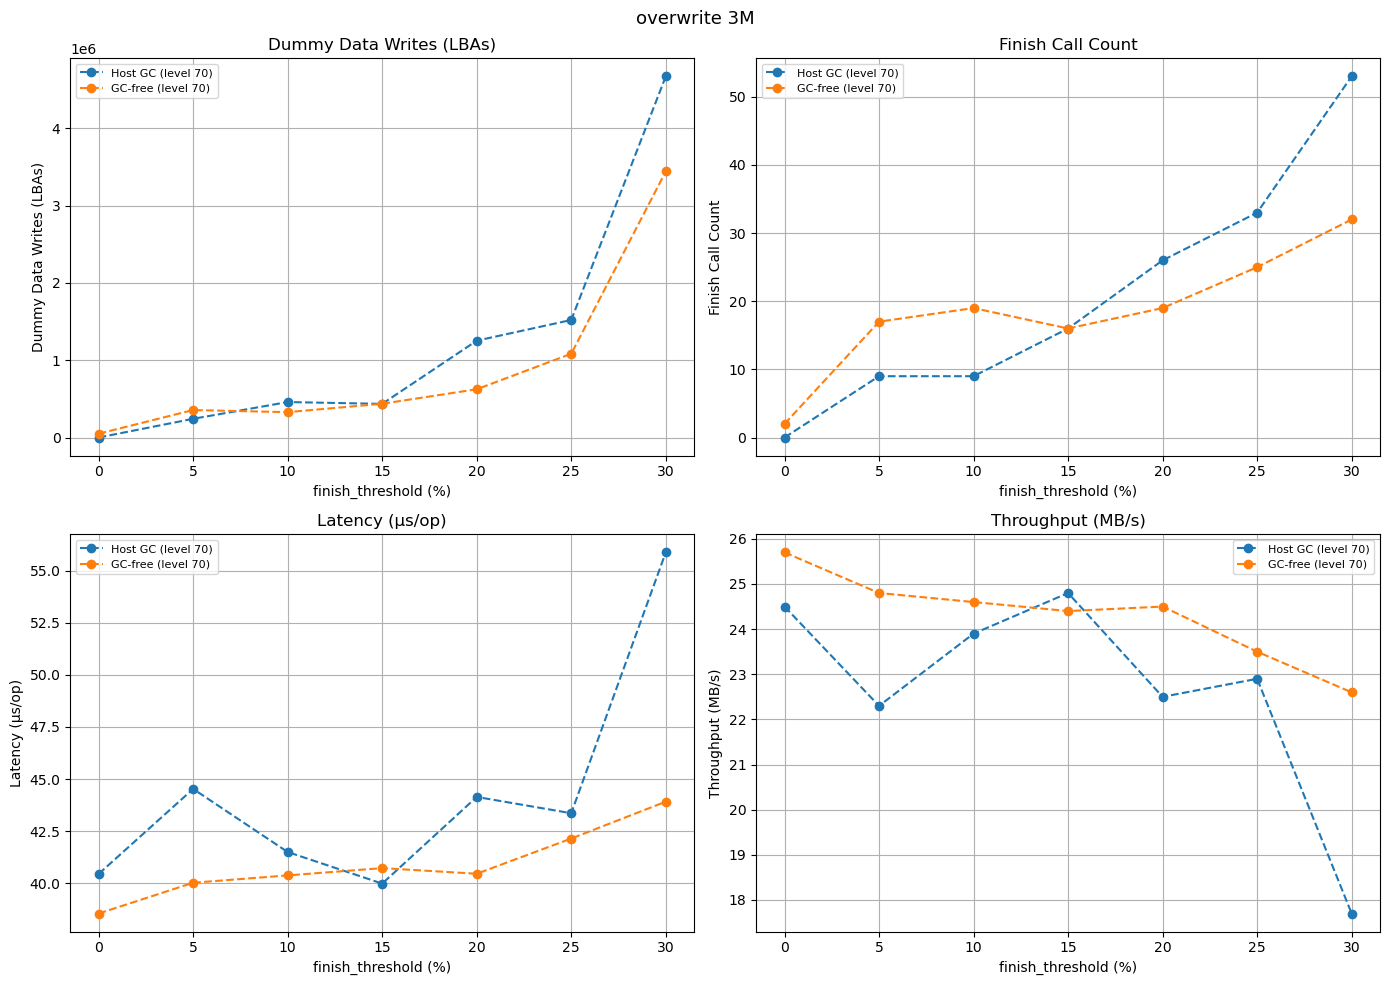

In [13]:
plot(
    "overwrite 3M",
    [
        "../results/exp5/overwrite_3M_gc70.csv",
        "../results/exp5/overwrite_3M_gcfalse.csv",
    ],
)

### Analysis: Is GC orthogonal to FINISH?

#### ZenFS GC selection logic

```cpp
uint64_t threshold = (100 - GC_SLOPE * (gc_start_level_ - free_percent));

for (const auto& zone : snapshot.zones_) {
  if (zone.capacity == 0) {  // only consider already full/finished zones
    uint64_t garbage_percent_approx =
        100 - 100 * zone.used_capacity / zone.max_capacity;
    if (garbage_percent_approx > threshold && garbage_percent_approx < 100) {
      migrate_zones_start.emplace(zone.start);
    }
  }
}
```

GC only reads from zones where `capacity == 0`, i.e. zones that are already full or explicitly FINISH'd. The selection loop never touches active (open) zones. Therefore, **GC and FINISH are orthogonal by design**: `gc_start_level` controls which already-closed zones are migrated, but it does not influence when an active zone gets FINISH'd.

Furthermore, the GC worker does not open a new zone to receive migrated data — it matches the best existing active zone. This means GC migration writes do not increase the total number of open zones, and cannot cause additional FINISH calls by creating new zones that would later need to be finished early.

#### Experimental results

**Figure 1 (3M ops, multiple `finish_threshold` values).**  
At low `finish_threshold` (e.g. 20–30%), the total data written (3M × 1040 B ≈ 3 GB) is not large enough to fill enough zones for GC to trigger. Despite GC being effectively inactive, the `finish_call_count` and `total_pages_to_write` still fluctuate noticeably across different `gc_start_level` values. This confirms the fluctuation is **measurement noise** from the random write pattern, not a causal effect of `gc_start_level`.

**Figure 2 (7M ops, `finish_threshold=20`).**  
With more data (7M ops ≈ 7 GB), GC does trigger. An upward trend in `finish_call_count` at high `gc_start_level` (≥70%) is visible. Given that GC is orthogonal to FINISH both by selection logic and by zone allocation (no new zones opened), this trend is most likely **measurement noise** from the random workload rather than a real GC effect. Confirming this would require more repeated runs.